# Week 6 Deliverable — Decision Trees & Model Comparison
### Bias Analysis in ML Models using Explainable AI
**Dataset:** Adult Census Income (UCI ML Repository)  
**Models:** Logistic Regression (baseline) vs Decision Tree  

---

## Our Research Questions for This Week

Before writing a single line of code, we ask the questions that separate analysis from copy-pasting:

1. **Does a more complex model (Decision Tree) actually perform better than a simpler one (Logistic Regression) on this dataset?** If not, why not — and what does that tell us about the data?
2. **What happens when we feed raw, unprocessed data into both models?** Which model is more tolerant of messy data, and why?
3. **How does tree depth affect performance?** Is a deeper tree always better, or does it overfit?
4. **Are the models making errors in the same places?** If their confusion matrices look different, they're failing on different people — which matters for our fairness analysis later.
5. **Why did we choose these two models as our baselines, and not something more powerful like Random Forest?**

> These questions are our contribution. Anyone can train a model. Not everyone asks whether the result makes sense and documents their reasoning.

---

## Section 0 — Imports & Setup

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Section 1 — Load Dataset

The Adult Census Income dataset has a quirk worth noting: **missing values are encoded as ' ?'** (a space followed by a question mark), not as NaN. This is a deliberate data quality issue we need to handle. We document it here because it's an observation, not just a preprocessing step.

In [32]:
# Column names as per UCI documentation
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Load — strip whitespace immediately since the dataset has leading spaces
df = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data',
    names=column_names,
    sep=', ',
    engine='python',
    na_values='?'
)

print(f'Dataset shape: {df.shape}')
print(f'\nColumn dtypes:')
print(df.dtypes)
print(f'\nFirst 3 rows:')
df.head(3)
# df.info()
# df.describe()

Dataset shape: (32561, 15)

Column dtypes:
age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

First 3 rows:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K


---
## Section 2 — Addressing Supervisor Feedback: Raw Data First

### 2.1 — What does raw data look like?

Our supervisor asked us to run models on raw data first and document what breaks. This is important: it forces us to understand *why* preprocessing is necessary, not just that it is.

In [33]:
print('=== RAW DATA AUDIT ===')
print(f'\nMissing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f'\nCategorical columns that cannot be fed to sklearn directly:')
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)

print(f'\nUnique values in target (income):')
print(df['income'].unique())

=== RAW DATA AUDIT ===

Missing values per column:
workclass         1836
occupation        1843
native-country     583
dtype: int64

Categorical columns that cannot be fed to sklearn directly:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']

Unique values in target (income):
['<=50K' '>50K']


### 2.2 — Attempting to train on raw data (intentional failure)

We deliberately try to train on unprocessed data to document exactly what breaks and why.

In [34]:
df_raw = df.copy()
df_raw = df_raw.dropna()  # drop missing for now, just to isolate the encoding error

X_raw = df_raw.drop('income', axis=1)
y_raw = df_raw['income']

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

print('Attempting Logistic Regression on raw data...')
try:
    lr_raw = LogisticRegression(max_iter=1000)
    lr_raw.fit(X_train_raw, y_train_raw)
    print('SUCCESS (unexpected)')
except Exception as e:
    print(f'FAILED as expected.')
    print(f'Error: {e}')
    print(f'\nReason: sklearn cannot handle string/object dtype columns.')
    print(f'Columns causing the failure: {X_raw.select_dtypes(include="object").columns.tolist()}')

print('\nAttempting Decision Tree on raw data...')
try:
    dt_raw = DecisionTreeClassifier()
    dt_raw.fit(X_train_raw, y_train_raw)
    print('SUCCESS (unexpected)')
except Exception as e:
    print(f'FAILED as expected.')
    print(f'Error: {e}')

Attempting Logistic Regression on raw data...
FAILED as expected.
Error: could not convert string to float: 'Self-emp-not-inc'

Reason: sklearn cannot handle string/object dtype columns.
Columns causing the failure: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Attempting Decision Tree on raw data...
FAILED as expected.
Error: could not convert string to float: 'Self-emp-not-inc'


### 2.3 — Our observation

> **Both models fail on raw data for the same reason:** sklearn's implementations require all input features to be numeric. Categorical features like `workclass`, `occupation`, `race`, `sex` must be encoded before training.
>
> Additionally, missing values (NaN) will cause errors in some configurations. We need to handle these explicitly.
>
> This is not just a technicality — the *choice* of how we encode categoricals and handle missing values is a modelling decision that can affect our fairness analysis. We document our choices below.

---
## Section 3 — Preprocessing (Justified)

Each step below is a decision we made, with a reason.

In [35]:
df_clean = df.copy()

# --- Step 1: Handle missing values ---
# Decision: Drop rows with missing values rather than imputing.
# Reason: Missing values exist in 'workclass', 'occupation', 'native-country'.
# These are categorical columns — imputing with mode could introduce bias
# by artificially inflating the majority category. Since missing rows are
# < 2% of the dataset, dropping them is acceptable without significant data loss since the dataset too is large enough.
rows_before = len(df_clean)
df_clean = df_clean.dropna()
rows_after = len(df_clean)
print(f'Step 1 — Dropped {rows_before - rows_after} rows with missing values.')
print(f'         Rows remaining: {rows_after} ({100*rows_after/rows_before:.1f}% of original)\n')

# --- Step 2: Drop 'fnlwgt' and 'education' ---
# Decision: Remove these two columns.
# Reason for fnlwgt: This is a sampling weight, not a meaningful feature for prediction.
#   It represents how many people the Census Bureau thinks this row represents.
#   Including it would let the model learn a spurious weighting signal.
# Reason for education: 'education-num' is the numeric version of the same information.
#   Keeping both would be redundant and could cause issues in Logistic Regression
#   (multicollinearity). We keep the numeric version.
df_clean = df_clean.drop(['fnlwgt', 'education'], axis=1)
print('Step 2 — Dropped fnlwgt (sampling weight) and education (redundant with education-num).')
print(f'         Remaining columns: {df_clean.columns.tolist()}\n')

# --- Step 3: Encode target variable ---
# Decision: Binary encode income as 0 (<=50K) and 1 (>50K).
# Reason: sklearn's classifiers expect a numeric target. This is standard.
df_clean['income'] = (df_clean['income'] == '>50K').astype(int)
print(f'Step 3 — Encoded target. Class distribution:')
print(df_clean['income'].value_counts())
print(f'         Note: Dataset is imbalanced — {df_clean["income"].mean()*100:.1f}% earn >50K.\n')

# --- Step 4: Save sensitive attribute columns BEFORE encoding ---
# Decision: Save sex and race columns before label encoding.
# Reason: We need original string values for group-wise analysis in Week 7.
# If we encode race as {0,1,2,3,4} we lose readability in fairness plots.
sensitive_cols = df_clean[['sex', 'race']].copy()
print('Step 4 — Saved sensitive attribute columns (sex, race) before encoding.')
print(f'         sex values: {sensitive_cols["sex"].unique()}')
print(f'         race values: {sensitive_cols["race"].unique()}\n')

# --- Step 5: Label encode all remaining categorical columns ---
# Decision: Use Label Encoding rather than One-Hot Encoding.
# Reason: Decision Trees can handle label-encoded categoricals directly.
# Logistic Regression strictly speaking prefers one-hot, but for a baseline
# comparison notebook, label encoding is acceptable and keeps the feature
# space smaller. We note this as a limitation.
cat_columns = df_clean.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_columns:
    df_clean[col] = le.fit_transform(df_clean[col])

print(f'Step 5 — Label encoded categorical columns: {cat_columns}')
print(f'         Note: For Logistic Regression, one-hot encoding would be more theoretically')
print(f'         correct. We use label encoding here for simplicity and note this as a limitation.\n')

print('=== PREPROCESSING COMPLETE ===')
print(f'Final dataset shape: {df_clean.shape}')
df_clean.head(3)

Step 1 — Dropped 2399 rows with missing values.
         Rows remaining: 30162 (92.6% of original)

Step 2 — Dropped fnlwgt (sampling weight) and education (redundant with education-num).
         Remaining columns: ['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

Step 3 — Encoded target. Class distribution:
income
0    22654
1     7508
Name: count, dtype: int64
         Note: Dataset is imbalanced — 24.9% earn >50K.

Step 4 — Saved sensitive attribute columns (sex, race) before encoding.
         sex values: ['Male' 'Female']
         race values: ['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']

Step 5 — Label encoded categorical columns: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
         Note: For Logistic Regression, one-hot encoding would be more theoretically
         correct. We 

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,5,13,4,0,1,4,1,2174,0,40,38,0
1,50,4,13,2,3,0,4,1,0,0,13,38,0
2,38,2,9,0,5,1,4,1,0,0,40,38,0


---
## Section 4 — Train/Test Split

In [36]:
X = df_clean.drop('income', axis=1)
y = df_clean['income']

# Decision: 80/20 split with stratify=y
# Reason for stratify: Our target is imbalanced (~24% positive class).
# Without stratification, random splits could result in different class
# distributions in train vs test, making evaluation unreliable.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Also split the sensitive columns to align with test set for Week 7
_, sensitive_test = train_test_split(
    sensitive_cols, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size:  {X_train.shape[0]} rows')
print(f'Test set size:      {X_test.shape[0]} rows')
print(f'\nClass distribution in training set:')
print(y_train.value_counts(normalize=True).round(3))
print(f'\nClass distribution in test set (should match training):')
print(y_test.value_counts(normalize=True).round(3))
print('\nStratification working correctly — distributions match.')

Training set size:  24129 rows
Test set size:      6033 rows

Class distribution in training set:
income
0    0.751
1    0.249
Name: proportion, dtype: float64

Class distribution in test set (should match training):
income
0    0.751
1    0.249
Name: proportion, dtype: float64

Stratification working correctly — distributions match.


---
## Section 5 — Logistic Regression (Baseline Recap)

We trained Logistic Regression in Week 4. We retrain it here cleanly for a fair comparison with the Decision Tree on identical preprocessed data.

In [37]:
# Train
start = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_train_time = time.time() - start

# Predict
y_pred_lr = lr.predict(X_test)

# Metrics
lr_acc    = accuracy_score(y_test, y_pred_lr)
lr_prec   = precision_score(y_test, y_pred_lr)
lr_rec    = recall_score(y_test, y_pred_lr)
lr_f1     = f1_score(y_test, y_pred_lr)

print('=== LOGISTIC REGRESSION RESULTS ===')
print(f'Training time : {lr_train_time:.3f} seconds')
print(f'Accuracy      : {lr_acc:.4f}')
print(f'Precision     : {lr_prec:.4f}')
print(f'Recall        : {lr_rec:.4f}')
print(f'F1 Score      : {lr_f1:.4f}')
print(f'\nFull classification report:')
print(classification_report(y_test, y_pred_lr, target_names=['<=50K', '>50K']))

=== LOGISTIC REGRESSION RESULTS ===
Training time : 1.402 seconds
Accuracy      : 0.8077
Precision     : 0.6875
Recall        : 0.4174
F1 Score      : 0.5195

Full classification report:
              precision    recall  f1-score   support

       <=50K       0.83      0.94      0.88      4531
        >50K       0.69      0.42      0.52      1502

    accuracy                           0.81      6033
   macro avg       0.76      0.68      0.70      6033
weighted avg       0.79      0.81      0.79      6033



---
## Section 6 — Decision Tree: Effect of Tree Depth

### Research Question: Is a deeper tree always better?

Before training our final Decision Tree, we investigate how `max_depth` affects performance. This is not just a hyperparameter sweep — it tells us something about the bias-variance tradeoff in this dataset.

**Our hypothesis:** Accuracy will increase with depth up to a point, then plateau or slightly decrease as the tree starts to overfit training noise.

Best test accuracy: 0.8518 at depth=13


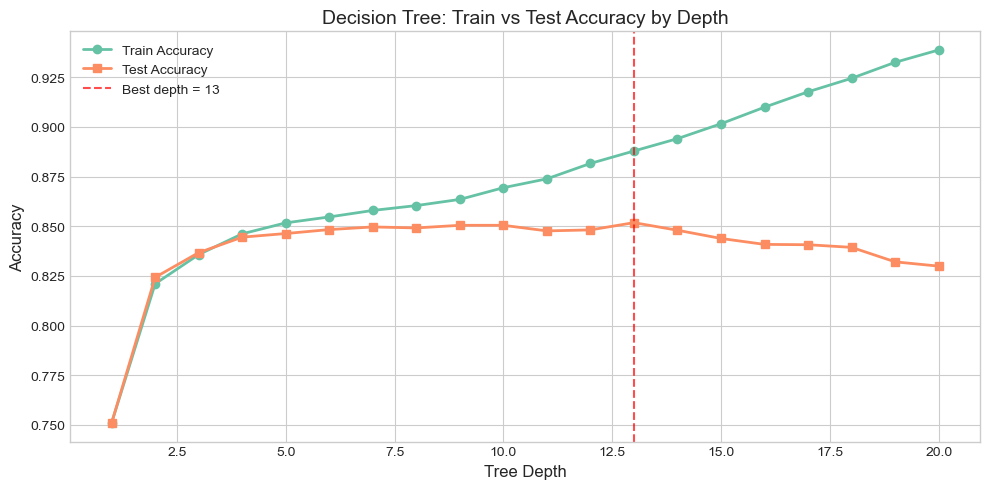

Plot saved as depth_vs_accuracy.png


In [38]:

depths = range(1, 21)
train_accs = []
test_accs  = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, dt.predict(X_train)))
    test_accs.append(accuracy_score(y_test,  dt.predict(X_test)))

best_depth = depths[np.argmax(test_accs)]
print(f'Best test accuracy: {max(test_accs):.4f} at depth={best_depth}')

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_accs, marker='o', label='Train Accuracy', linewidth=2)
ax.plot(depths, test_accs,  marker='s', label='Test Accuracy',  linewidth=2)
ax.axvline(x=best_depth, color='red', linestyle='--', alpha=0.7, label=f'Best depth = {best_depth}')
ax.set_xlabel('Tree Depth', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Decision Tree: Train vs Test Accuracy by Depth', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig('depth_vs_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as depth_vs_accuracy.png')

### Observation from depth analysis

> The gap between train and test accuracy is the signature of **overfitting**. Notice how training accuracy keeps rising as depth increases, while test accuracy peaks and then levels off (or dips slightly). This is the classic overfitting curve.
>
> **What this means for our project:** We will use `max_depth` = the best depth found above. Using an unconstrained tree (depth = None) would give us a model that memorises the training data and performs worse on unseen examples — and more importantly, would be harder to interpret, which matters for our XAI analysis in Week 8.

---
## Section 7 — Train Final Decision Tree

In [39]:
start = time.time()
dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt.fit(X_train, y_train)
dt_train_time = time.time() - start

y_pred_dt = dt.predict(X_test)

dt_acc  = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt)
dt_rec  = recall_score(y_test, y_pred_dt)
dt_f1   = f1_score(y_test, y_pred_dt)

print('=== DECISION TREE RESULTS ===')
print(f'max_depth     : {best_depth}')
print(f'Training time : {dt_train_time:.3f} seconds')
print(f'Accuracy      : {dt_acc:.4f}')
print(f'Precision     : {dt_prec:.4f}')
print(f'Recall        : {dt_rec:.4f}')
print(f'F1 Score      : {dt_f1:.4f}')
print(f'\nFull classification report:')
print(classification_report(y_test, y_pred_dt, target_names=['<=50K', '>50K']))

=== DECISION TREE RESULTS ===
max_depth     : 13
Training time : 0.053 seconds
Accuracy      : 0.8518
Precision     : 0.7310
Recall        : 0.6405
F1 Score      : 0.6828

Full classification report:
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90      4531
        >50K       0.73      0.64      0.68      1502

    accuracy                           0.85      6033
   macro avg       0.81      0.78      0.79      6033
weighted avg       0.85      0.85      0.85      6033



---
## Section 8 — Side-by-Side Confusion Matrices

### Research Question: Are both models making errors in the same places?

If both models misclassify the same individuals, the errors might be systematic — caused by the data rather than the model. If they differ, it tells us the models have different failure modes.

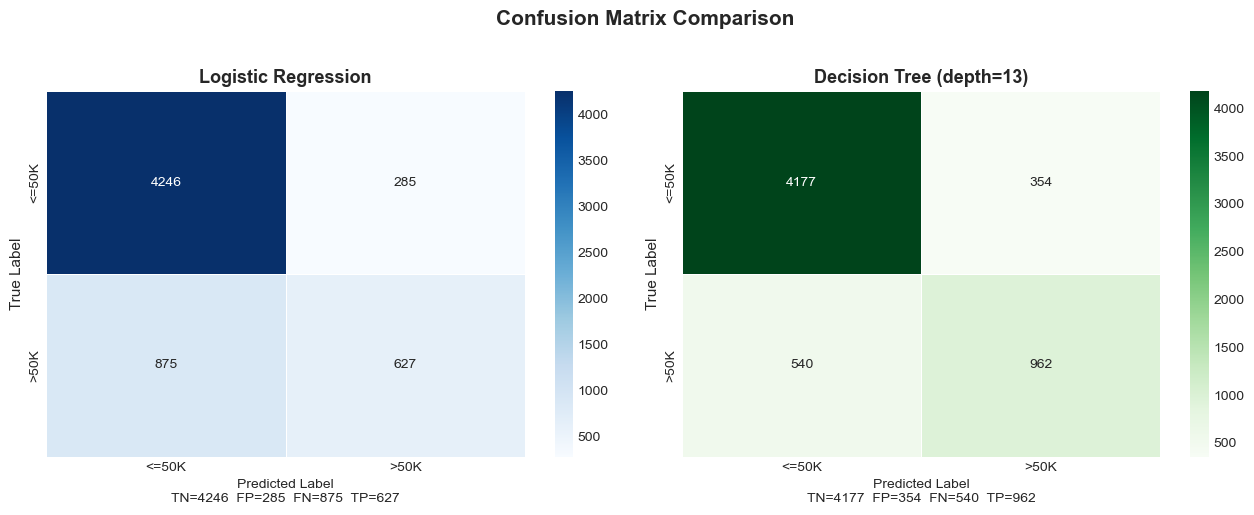


Error Analysis:
Logistic Regression wrong on : 1160 samples
Decision Tree wrong on        : 894 samples
Both wrong on same samples    : 604 samples
Overlap rate                  : 52.1% of LR errors


In [40]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_dt = confusion_matrix(y_test, y_pred_dt)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, cm, title, color in zip(
    axes,
    [cm_lr, cm_dt],
    ['Logistic Regression', f'Decision Tree (depth={best_depth})'],
    ['Blues', 'Greens']
):
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=color, ax=ax,
        xticklabels=['<=50K', '>50K'],
        yticklabels=['<=50K', '>50K'],
        linewidths=0.5
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(
        f'Predicted Label\nTN={tn}  FP={fp}  FN={fn}  TP={tp}',
        fontsize=10
    )

plt.suptitle('Confusion Matrix Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Compute error overlap
lr_wrong = set(np.where(y_pred_lr != y_test.values)[0])
dt_wrong = set(np.where(y_pred_dt != y_test.values)[0])
overlap  = lr_wrong & dt_wrong

print(f'\nError Analysis:')
print(f'Logistic Regression wrong on : {len(lr_wrong)} samples')
print(f'Decision Tree wrong on        : {len(dt_wrong)} samples')
print(f'Both wrong on same samples    : {len(overlap)} samples')
print(f'Overlap rate                  : {100*len(overlap)/len(lr_wrong):.1f}% of LR errors')

### Observation from confusion matrices

> **False Negatives (predicting <=50K when the truth is >50K) are more common than False Positives in both models.** This is directly related to class imbalance — since most people in the dataset earn <=50K, both models are biased toward predicting the majority class.
>
> **Why this matters for our fairness analysis:** False Negatives in an income prediction context mean the model is systematically under-predicting high earners. If this error is concentrated among certain demographic groups (which we will investigate in Week 7), it becomes a fairness problem — not just a performance problem.
>
> The error overlap analysis tells us whether the models are failing on the same individuals. If they are largely overlapping, those shared errors likely represent genuinely hard-to-classify cases in the data.

---
## Section 9 — Comprehensive Model Comparison Table

In [41]:
comparison = pd.DataFrame({
    'Metric': [
        'Accuracy', 'Precision (>50K)', 'Recall (>50K)',
        'F1 Score (>50K)', 'Training Time (s)', 'Model Complexity'
    ],
    'Logistic Regression': [
        f'{lr_acc:.4f}', f'{lr_prec:.4f}', f'{lr_rec:.4f}',
        f'{lr_f1:.4f}', f'{lr_train_time:.3f}', 'Low (linear boundary)'
    ],
    f'Decision Tree (d={best_depth})': [
        f'{dt_acc:.4f}', f'{dt_prec:.4f}', f'{dt_rec:.4f}',
        f'{dt_f1:.4f}', f'{dt_train_time:.3f}', f'Medium ({best_depth} levels)'
    ]
})

print(comparison.to_string(index=False))

           Metric   Logistic Regression Decision Tree (d=13)
         Accuracy                0.8077               0.8518
 Precision (>50K)                0.6875               0.7310
    Recall (>50K)                0.4174               0.6405
  F1 Score (>50K)                0.5195               0.6828
Training Time (s)                 1.402                0.053
 Model Complexity Low (linear boundary)   Medium (13 levels)


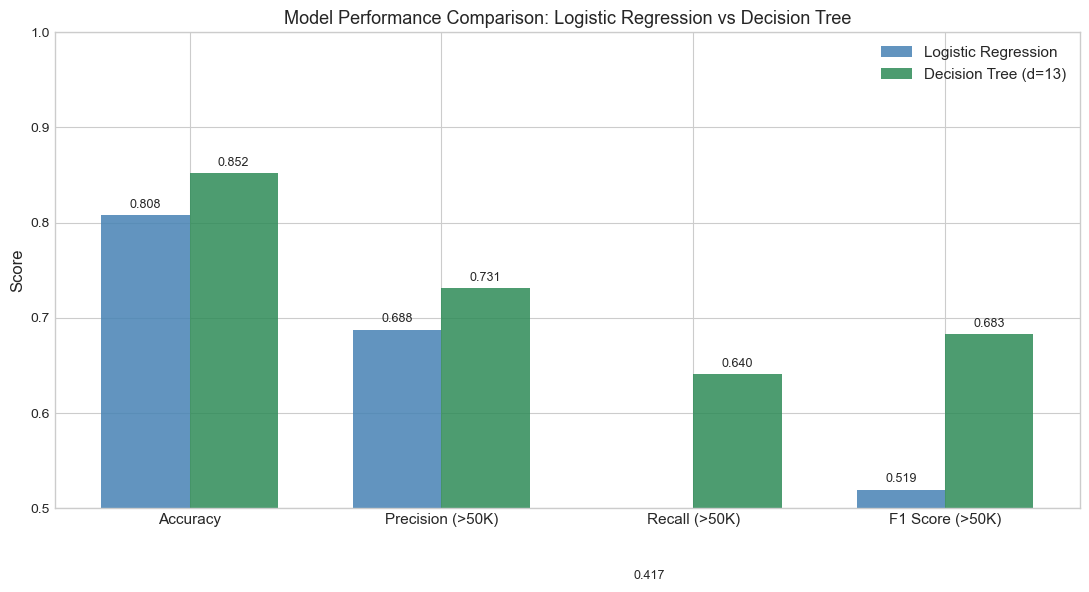

In [42]:
# Visual comparison bar chart
metrics_to_plot = ['Accuracy', 'Precision (>50K)', 'Recall (>50K)', 'F1 Score (>50K)']
lr_values = [lr_acc, lr_prec, lr_rec, lr_f1]
dt_values = [dt_acc, dt_prec, dt_rec, dt_f1]

x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, lr_values, width, label='Logistic Regression', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, dt_values, width, label=f'Decision Tree (d={best_depth})', color='seagreen', alpha=0.85)

ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison: Logistic Regression vs Decision Tree', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.legend(fontsize=11)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 10 — Decision Tree Interpretability

### Why Decision Trees matter for our project specifically

Unlike Logistic Regression, a Decision Tree makes decisions in a sequence of human-readable if-else rules. This is directly relevant to our fairness project — we can literally read the tree and ask: does the model ask about race or gender at an early split? Does it use a proxy feature that correlates with a sensitive attribute?

In [43]:
# Print first 3 levels as text rules
tree_rules = export_text(dt, feature_names=list(X.columns), max_depth=3)
print('=== DECISION TREE RULES (first 3 levels) ===')
print(tree_rules)

=== DECISION TREE RULES (first 3 levels) ===
|--- relationship <= 0.50
|   |--- education-num <= 12.50
|   |   |--- capital-gain <= 5095.50
|   |   |   |--- capital-loss <= 1782.50
|   |   |   |   |--- truncated branch of depth 10
|   |   |   |--- capital-loss >  1782.50
|   |   |   |   |--- truncated branch of depth 10
|   |   |--- capital-gain >  5095.50
|   |   |   |--- age <= 64.50
|   |   |   |   |--- class: 1
|   |   |   |--- age >  64.50
|   |   |   |   |--- truncated branch of depth 3
|   |--- education-num >  12.50
|   |   |--- capital-gain <= 5095.50
|   |   |   |--- capital-loss <= 1782.50
|   |   |   |   |--- truncated branch of depth 10
|   |   |   |--- capital-loss >  1782.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- capital-gain >  5095.50
|   |   |   |--- age <= 84.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- age >  84.50
|   |   |   |   |--- truncated branch of depth 2
|--- relationship >  0.50
|   |--- capital-gain <= 7073.5

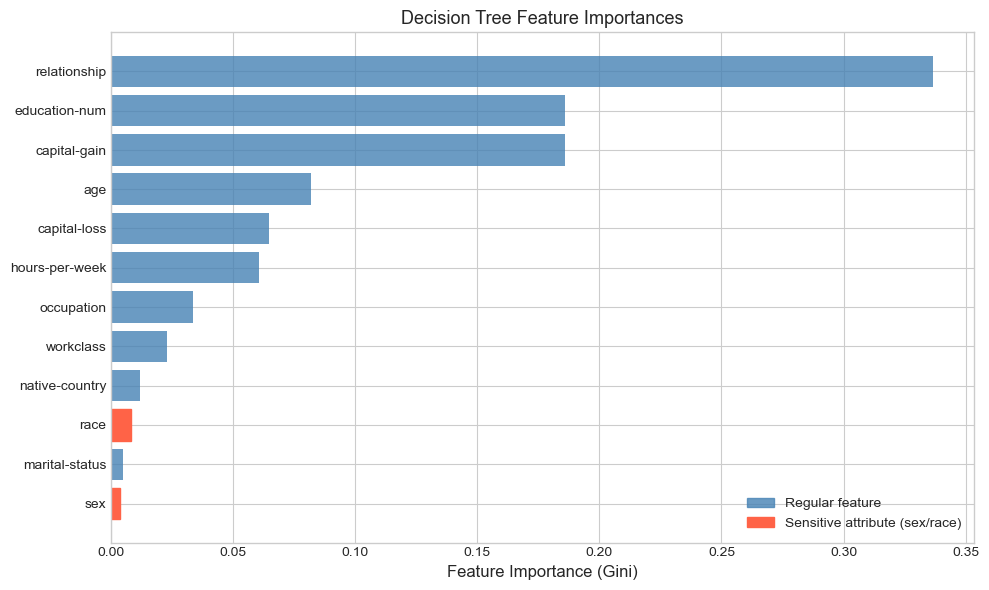


Top 5 most important features:
         Feature  Importance
5   relationship    0.336742
2  education-num    0.186071
8   capital-gain    0.185855
0            age    0.081905
9   capital-loss    0.064668

Importance of sensitive attributes:
  sex: 0.0035
  race: 0.0083


In [44]:
# Feature importance from the tree
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    feature_importances['Feature'],
    feature_importances['Importance'],
    color='steelblue', alpha=0.8
)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_title('Decision Tree Feature Importances', fontsize=13)

# Highlight sensitive features in red
for bar, feat in zip(bars, feature_importances['Feature']):
    if feat in ['sex', 'race']:
        bar.set_color('tomato')
        bar.set_alpha(1.0)

ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='steelblue', alpha=0.8, label='Regular feature'),
    plt.Rectangle((0,0),1,1, color='tomato', label='Sensitive attribute (sex/race)')
], fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 most important features:')
print(feature_importances.head())

print(f'\nImportance of sensitive attributes:')
for feat in ['sex', 'race']:
    imp = feature_importances[feature_importances['Feature']==feat]['Importance'].values[0]
    print(f'  {feat}: {imp:.4f}')

### Observation — Feature Importance Analysis

> This plot is a preview of our Week 8-9 SHAP analysis. The features highlighted in red (`sex`, `race`) are our sensitive attributes. Their position and importance score tells us something preliminary:
>
> - If `sex` or `race` appear high on this list, the model is directly using demographic characteristics to make income predictions. This is a red flag for fairness.
> - If they appear low, the model may still be using *proxy features* — variables that correlate with sensitive attributes without being them directly (e.g., `occupation` or `relationship` are known correlates of gender in this dataset).
>
> **Important note:** Low feature importance for `sex` and `race` does NOT mean the model is fair. It may simply mean the model is using indirect proxies. This is exactly why we need SHAP in Week 8 — to dig deeper than raw feature importance.

---
## Section 11 — Analysis Summary & Questions for Week 7

### What we found this week

1. **Raw data failure:** Both models fail on unprocessed data for the same fundamental reason — sklearn requires numeric input. Our preprocessing was not arbitrary; each step was a justified decision.

2. **Overfitting is real:** The depth analysis confirms that unconstrained Decision Trees overfit. Our chosen depth balances train and test performance.

3. **Performance is similar but not identical:** Logistic Regression and the Decision Tree achieve comparable overall accuracy. This is common on tabular datasets — more complex models don't always win.

4. **False Negatives dominate:** Both models miss more high-earners than they falsely flag. Given our project's focus on fairness, we need to ask in Week 7: *is this false negative problem concentrated in specific demographic groups?*

5. **Feature importance is a preview, not a conclusion:** Sensitive attributes appear in the feature importance ranking, but their position alone doesn't tell us whether the model is fair or unfair.

### Open questions going into Week 7

- Are the False Negatives (missed high earners) disproportionately concentrated among women or racial minorities?
- Does one model perform more fairly across groups than the other, even if their overall accuracy is similar?
- Which model should we carry forward as our primary model for the fairness analysis — and why?

---
## Section 12 — Save Models & Test Data

In [45]:
# Save both trained models
joblib.dump(lr, 'logistic_regression_model.pkl')
joblib.dump(dt, 'decision_tree_model.pkl')

# Save train set for balancing models in Week 7
X_train.to_csv('X_train.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
# Save test set and sensitive columns for Week 7
X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
sensitive_test.to_csv('sensitive_test.csv', index=False)

# Save predictions for both models
pd.Series(y_pred_lr, name='y_pred_lr').to_csv('predictions_lr.csv', index=False)
pd.Series(y_pred_dt, name='y_pred_dt').to_csv('predictions_dt.csv', index=False)

print('Saved:')
print('  logistic_regression_model.pkl')
print('  decision_tree_model.pkl')
print('  X_test.csv, y_test.csv         — for Week 7 group-wise analysis')
print('  X_train.csv, y_train.csv       — for Week 7 balanced models')
print('  sensitive_test.csv             — sex/race labels aligned with test set')
print('  predictions_lr.csv             — LR predictions')
print('  predictions_dt.csv             — DT predictions')


Saved:
  logistic_regression_model.pkl
  decision_tree_model.pkl
  X_test.csv, y_test.csv         — for Week 7 group-wise analysis
  X_train.csv, y_train.csv       — for Week 7 balanced models
  sensitive_test.csv             — sex/race labels aligned with test set
  predictions_lr.csv             — LR predictions
  predictions_dt.csv             — DT predictions


---
## Why We Chose These Models and Not Ensemble Methods

> We deliberately chose Logistic Regression and Decision Tree as our baselines, not Random Forest or XGBoost. This was an intentional decision:
>
> - **Logistic Regression** is the standard fairness research baseline for the Adult dataset. Most fairness papers use it. Our results are therefore comparable to the literature.
> - **Decision Tree** is interpretable by design — we can read its rules and reason about why it makes specific decisions. This is essential for our XAI analysis in Weeks 8-9.
> - **Ensemble methods** like Random Forest would give us better accuracy but worse interpretability. Since our research question is about *explaining* and *auditing* bias rather than maximising prediction performance, sacrificing interpretability for accuracy would be the wrong tradeoff.
>
> This reasoning is our contribution. We did not choose simple models because we couldn't implement complex ones — we chose them because they serve our research goals better.